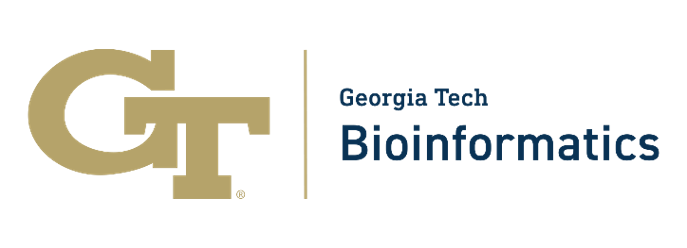

<div class="alert alert-block alert-info">
    <h1>BIOL 4150/BIOL 6150</h1>
    <h3>Instructor: Dr. King Jordan</h3>
    <p>Nilavrah Sensarma (nsensarma3@gatech.edu)</p>
    <p>Valli Sree Lasya Pasumarthy (vpasumarthy3@gatech.edu)

</p>
</div>

<div class="alert alert-block alert-warning">
    <h2>Project 3 (Read Mapping & Variant Calling) starter notebook</h2>
    <h3>Deadline: 11:59PM, September 29th, 2025</h3>
</div>

### Rerun the analysis as demonstrated in the lab sessions


---

<div class="alert alert-block alert-warning">
    <h2>Part 1 - Read Mapping</h2>
    <h2> Total Points: 5+15+15 = 35</h2>
</div>

# **1.1 Getting read for read alignment**
### *Total Questions: 5*
### *Total Points: 0.5+0.5+1+2+1 = 5*


---

<div class="alert alert-block alert-warning">
    <h3>1.1.1 Do you have the post-QCed fastq file from the assigned 1000 Genomes individual</h3>
    <p>We will start from where we left off in Project #1. We want to make sure that we are using the correct QCed fastq files.</p>
</div>

In [1]:
##Run "ls -lh" here to show the two fastq files.
!ls -lh ~/biol6150/SharedEnvironment/group4/project1data/Trimming/

total 3.8G
-rwxrwxrwx. 1 jrust8 gtperson 1.9G Sep 25 14:16 SRR360498_1.Trimmed.filt.fastq.gz
-rwxrwxrwx. 1 jrust8 gtperson 2.0G Sep 25 14:16 SRR360498_2.Trimmed.filt.fastq.gz


<div class="alert alert-block alert-warning">
    <h3>1.1.2 Download the correct reference genome for alignment step</h3>
    <p>Please locate and donwload the human reference genome fasta file in build GRCh38</p>
</div>

#### Where does this file come from? Give the website link (FTP?) or explain how you downloaed this file.
The file comes from the NCBI FTP server. It is the human reference genome GRCh38. It was downloaded using wget which retrieves files directly from a URL.


In [2]:
!wget https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/001/405/GCF_000001405.26_GRCh38/GCF_000001405.26_GRCh38_genomic.fna.gz
!ls -lh GCF_000001405.26_GRCh38_genomic.fna.gz

--2026-10-07 17:54:42--  https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/001/405/GCF_000001405.26_GRCh38/GCF_000001405.26_GRCh38_genomic.fna.gz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.12, 130.14.250.13, 2607:f220:41e:250::10, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.12|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 946060496 (902M) [application/x-gzip]
Saving to: ‘GCF_000001405.26_GRCh38_genomic.fna.gz’

GCF_000001405.26_GR 100%[===================>] 902.23M   165MB/s    in 5.5s    

2026-10-07 17:54:48 (163 MB/s) - ‘GCF_000001405.26_GRCh38_genomic.fna.gz’ saved [946060496/946060496]

-rw-r--r--. 1 cechcharef3 gtperson 903M Aug 19  2025 GCF_000001405.26_GRCh38_genomic.fna.gz


In [4]:
!mkdir -p ~/biol6150/ProjectSubmissions/Group4/Project2/ReadAlignment/
!mv GCF_000001405.26_GRCh38_genomic.fna.gz ~/biol6150/ProjectSubmissions/Group4/Project2/ReadAlignment/
!ls -lh ~/biol6150/ProjectSubmissions/Group4/Project2/ReadAlignment/

total 903M
-rw-r--r--. 1 cechcharef3 gtperson 903M Aug 19  2025 GCF_000001405.26_GRCh38_genomic.fna.gz


<div class="alert alert-block alert-warning">
    <h3>1.1.3 Find out about your reference genome file.</h3>
    <p>Does your reference fasta file have more information that just ACGT nucleotides? Please check if your fastq sequence have Ns or small/upper case ACGT nnucleotides.</p>
</div>

In [5]:
!gunzip ~/biol6150/ProjectSubmissions/Group4/Project2/ReadAlignment/GCF_000001405.26_GRCh38_genomic.fna.gz

In [6]:
!ls -lh ReadAlignment/
!head ~/biol6150/ProjectSubmissions/Group4/Project2/ReadAlignment/GCF_000001405.26_GRCh38_genomic.fna
!head ~/biol6150/ProjectSubmissions/Group4/Project2/ReadAlignment/GCF_000001405.26_GRCh38_genomic.fna -n20000 | tail

total 26G
-rw-r--r--. 1 cechcharef3 gtperson  88M Mar 20  2009 chr16.fa
-rw-r--r--. 1 cechcharef3 gtperson  111 Sep 25 12:41 chr16.fa.amb
-rw-r--r--. 1 cechcharef3 gtperson   42 Sep 25 12:41 chr16.fa.ann
-rw-r--r--. 1 cechcharef3 gtperson  87M Sep 25 12:40 chr16.fa.bwt
-rw-r--r--. 1 cechcharef3 gtperson  22M Sep 25 12:41 chr16.fa.pac
-rw-r--r--. 1 cechcharef3 gtperson  44M Sep 25 12:41 chr16.fa.sa
-rw-r--r--. 1 cechcharef3 gtperson 246M Sep 25 13:26 chr16.mmi
-rw-r--r--. 1 cechcharef3 gtperson  13G Sep 25 13:29 SRR710118.Minimap.sam
-rw-r--r--. 1 cechcharef3 gtperson  13G Sep 25 13:25 SRR710118.sam
>NC_000001.11 Homo sapiens chromosome 1, GRCh38 Primary Assembly
NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN
NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN
NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN
NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN
NNNNN

### Write in one sentence if you see more than just upper case ACGT nucleotides.
The FASTA file contains more than uppercase ACGT nucleotides, it also contains N nucleotides and lowercase letters acgt.

<div class="alert alert-block alert-warning">
    <h3>1.1.4 Using 1-3 lines, explain what upper case ACGT, lower case ACGT, and NNNs mean in your reference fasta file.</h3>
    <p>Hint: check readme files.</p>
</div>

#No need to exceed 3 lines for this question.
- Uppercase ACGT: confidently determined DNA bases, non-repetitive sequence.
- Lowercase ACGT: DNA bases in regions that are soft-masked, often indicating repetitive or low-complexity regions.
- NNNs: unknown or undetermined bases, often representing gaps in the reference genome or the telomere and adjacent regions

<div class="alert alert-block alert-warning">
    <h3>1.1.5 Select a tool for read alignment.</h3>
    <p>We have demonstrated bwa and minimap2 in the class. Use either of the tools for this section.</p>
</div>

In [1]:
#Run your tool here to just make sure bash does not say "not found"
!bwa index 


Usage:   bwa index [options] <in.fasta>

Options: -a STR    BWT construction algorithm: bwtsw, is or rb2 [auto]
         -p STR    prefix of the index [same as fasta name]
         -b INT    block size for the bwtsw algorithm (effective with -a bwtsw) [10000000]
         -6        index files named as <in.fasta>.64.* instead of <in.fasta>.* 

         `-a div' do not work not for long genomes.



# **1.2 Read alignment**
### *Total Questions: 4*
### *Total Points: 2+3+2+8= 15*

---

<div class="alert alert-block alert-warning">
    <h3>1.2.1 Steps before mapping</h3>
    <p>You already have a fasta file, but sometimes alignment tools do not accept fasta files directly. Please read your aligners documentation and run all the preliminary steps require to run the mapping command from your aligner.</p>
</div>

<div class="alert alert-block alert-info">
    <p>Preliminary commands go in the cells below. Please use appropriate comments and markdown texts to explain what your command is doing.</p>
</div>

In [2]:
!bwa index -a rb2 ~/biol6150/ProjectSubmissions/Group4/Project2/ReadAlignment/GCF_000001405.26_GRCh38_genomic.fna

[bwa_index] Pack FASTA... 14.03 sec
[bwa_index] Construct BWT for the packed sequence...
[bwa_index] 4455.58 seconds elapse.
[bwa_index] Update BWT... 8.81 sec
[bwa_index] Pack forward-only FASTA... 8.33 sec
[bwa_index] Construct SA from BWT and Occ... 648.35 sec
[main] Version: 0.7.17-r1188
[main] CMD: bwa index -a rb2 /home/hice1/cechcharef3/biol6150/ProjectSubmissions/Group4/Project2/ReadAlignment/GCF_000001405.26_GRCh38_genomic.fna
[main] Real time: 5184.358 sec; CPU: 5135.097 sec


In [3]:
#Run "ls -lh" to show what additional files were created in addition to your original fasta files.
!ls -lh ~/biol6150/ProjectSubmissions/Group4/Project2/ReadAlignment/

total 8.3G
-rw-r--r--. 1 cechcharef3 gtperson 3.1G Aug 19  2025 GCF_000001405.26_GRCh38_genomic.fna
-rw-r--r--. 1 cechcharef3 gtperson  21K Oct  7 19:15 GCF_000001405.26_GRCh38_genomic.fna.amb
-rw-r--r--. 1 cechcharef3 gtperson  58K Oct  7 19:15 GCF_000001405.26_GRCh38_genomic.fna.ann
-rw-r--r--. 1 cechcharef3 gtperson 3.0G Oct  7 19:15 GCF_000001405.26_GRCh38_genomic.fna.bwt
-rw-r--r--. 1 cechcharef3 gtperson 766M Oct  7 19:15 GCF_000001405.26_GRCh38_genomic.fna.pac
-rw-r--r--. 1 cechcharef3 gtperson 1.5G Oct  7 19:26 GCF_000001405.26_GRCh38_genomic.fna.sa


<div class="alert alert-block alert-warning">
    <h3>1.2.2 Run mapping.</h3>
    <p>This should be one or two lines of code but it's important to understand what the options are doing.</p>
</div>

In [4]:
#Write you command below.

!bwa mem -t 24 ~/biol6150/ProjectSubmissions/Group4/Project2/ReadAlignment/GCF_000001405.26_GRCh38_genomic.fna ~/biol6150/SharedEnvironment/group4/project1data/Trimming/SRR360498_1.Trimmed.filt.fastq.gz ~/biol6150/SharedEnvironment/group4/project1data/Trimming/SRR360498_2.Trimmed.filt.fastq.gz > ~/biol6150/ProjectSubmissions/Group4/Project2/ReadAlignment/SRR360498.sam

[M::bwa_idx_load_from_disk] read 0 ALT contigs
[M::process] read 3288734 sequences (240000102 bp)...
[M::process] read 3288770 sequences (240000120 bp)...
[M::mem_pestat] # candidate unique pairs for (FF, FR, RF, RR): (163, 1293330, 39, 160)
[M::mem_pestat] analyzing insert size distribution for orientation FF...
[M::mem_pestat] (25, 50, 75) percentile: (426, 853, 1400)
[M::mem_pestat] low and high boundaries for computing mean and std.dev: (1, 3348)
[M::mem_pestat] mean and std.dev: (927.13, 722.81)
[M::mem_pestat] low and high boundaries for proper pairs: (1, 4322)
[M::mem_pestat] analyzing insert size distribution for orientation FR...
[M::mem_pestat] (25, 50, 75) percentile: (169, 205, 251)
[M::mem_pestat] low and high boundaries for computing mean and std.dev: (5, 415)
[M::mem_pestat] mean and std.dev: (212.74, 60.85)
[M::mem_pestat] low and high boundaries for proper pairs: (1, 497)
[M::mem_pestat] analyzing insert size distribution for orientation RF...
[M::mem_pestat] (25, 50, 

In [13]:
!head -n3 ~/biol6150/ProjectSubmissions/Group4/Project2/ReadAlignment/SRR360498.sam  | tail -n1

@SQ	SN:NT_187362.1	LN:32032


### Explain each argument/flag that was given to the mapping command.
- bwa mem: runs the algorithm for aligning sequencing reads to a reference genome.
- -t 24: uses 24 CPU threads to speed up the alignment.
- GCF_000001405.26_GRCh38_genomic.fna : the reference genome FASTA file (GRCh38).
- SRR360498_1.Trimmed.filt.fastq.gz : the forward/read 1 paired-end FASTQ file.
- SRR360498_2.Trimmed.filt.fastq.gz : the reverse/read 2 paired-end FASTQ file.
- \> : redirects the output into a file instead of displaying it in the terminal.
- SRR360498.sam : the output SAM file containing the read alignments.

<div class="alert alert-block alert-warning">
    <h3>1.2.3 Post alignment evaluation.</h3>
    <p>How many lines does your SAM file have?</p>
</div>

In [14]:
#Just one line for this one.
!wc ~/biol6150/ProjectSubmissions/Group4/Project2/ReadAlignment/SRR360498.sam

   60351514   972438791 15849239805 /home/hice1/cechcharef3/biol6150/ProjectSubmissions/Group4/Project2/ReadAlignment/SRR360498.sam


<div class="alert alert-block alert-warning">
    <h3>1.2.4 Look at the 7th read that maps successfully in your SAM file and answer the following questions.                     (4*2 = 8 points)</h3>
    <p>1. What chromosome does it align to?</p>
    <p>2. What is the CIGAR string for this read? Explain the CIGAR string in detail.</p>
    <p>3. Does this read have a paired read which also aligns successfully?</p>
    <p>4. If the paired read aligns successfully, what does the CIGAR string for this read convey?</p>
</div>

In [27]:
!samtools view -F 4 ~/biol6150/ProjectSubmissions/Group4/Project2/ReadAlignment/SRR360498.sam | head -7 | tail -1

SRR360498.876	83	NC_000001.11	203498739	60	73M	=	203498631	-181	TGACCTAGAGGACATTCCTCCTCTTCCTCGGAGGACTGCCTACCTGTATGCACGCTTCAACCGCATCAGCCGT	%%%%%%%%%%%%%%%@DDBBD@DDACC@CCG@GEE<8GGBHEHHHGGEGEEEGDEGGEGBGGBGGBHHDHHHH	NM:i:0	MD:Z:73	MC:Z:73M	AS:i:73	XS:i:0
samtools view: writing to standard output failed: Broken pipe
samtools view: error closing standard output: -1


#### What chromosome does it align to?
- Chromosome 1 (NC_000001.11).
#### What is the CIGAR string for this read? Explain the CIGAR string in detail.
- 73M — all 73 bases of the read align to the reference with no insertions, deletions, or clipping.
#### Does this read have a paired read which also aligns successfully?
- Yes. The FLAG 83 indicates this is the second read in a paired-end read, and the mate is mapped.
#### If the paired read aligns successfully, what does the CIGAR string for this read convey?
- The MC:Z:73M tag indicates that the paired read also has a 73M CIGAR string, all 73 bases of the mate align continuously to the reference.

# **1.3 Read alignment evaluation**
### *Total Questions: 5*
### *Total Points: 2+2+3+2+6 = 15*


---

<div class="alert alert-block alert-warning">
    <h3>1.3.1 Samtools is a classic bioinformatics tools.</h3>
    <p>Check if you have samtools installed on your environment.</p>
</div>

In [7]:
#Just run the "samtools" command here and make sure it does not say "samtools not found".
!samtools


Program: samtools (Tools for alignments in the SAM format)
Version: 1.17 (using htslib 1.17)

Usage:   samtools <command> [options]

Commands:
  -- Indexing
     dict           create a sequence dictionary file
     faidx          index/extract FASTA
     fqidx          index/extract FASTQ
     index          index alignment

  -- Editing
     calmd          recalculate MD/NM tags and '=' bases
     fixmate        fix mate information
     reheader       replace BAM header
     targetcut      cut fosmid regions (for fosmid pool only)
     addreplacerg   adds or replaces RG tags
     markdup        mark duplicates
     ampliconclip   clip oligos from the end of reads

  -- File operations
     collate        shuffle and group alignments by name
     cat            concatenate BAMs
     consensus      produce a consensus Pileup/FASTA/FASTQ
     merge          merge sorted alignments
     mpileup        multi-way pileup
     sort           sort alignment file
     split          splits a

<div class="alert alert-block alert-warning">
    <h3>1.3.2 Is your SAM file sorted by coordinates?</h3>
    <p>SAM or BAM (which we will create later) can be sorted by the read name or read coordinate. Look at your SAM file and see if you can run a Samtools command to find out if your file is sorted. (Hint: Google your question)</p>
</div>

In [34]:
#Tell us if your SAM file is sorted.
!samtools view ~/biol6150/ProjectSubmissions/Group4/Project2/ReadAlignment/SRR360498.sam | head -n 10 | cut -f 1-4

samtools view: SRR360498.870	99	NC_000002.12	119630510
writing to standard output failedSRR360498.870	147	NC_000002.12	119630709
: Broken pipe
SRR360498.873	99	NC_000002.12	26940001
SRR360498.873	147	NC_000002.12	26940101
SRR360498.875	99	NC_000019.10	56524971
samtools view: SRR360498.875	147	NC_000019.10	56525097
error closing standard output: -1SRR360498.876	83	NC_000001.11	203498739

SRR360498.876	163	NC_000001.11	203498631
SRR360498.886	99	NC_000011.10	8452821
SRR360498.886	147	NC_000011.10	8452957


#### Tell us how you reached your answer and clerly write the commands used in additional cell with descriptive comments.

The SAM file is not sorted. The header has no @HD SO:coordinate tag, and the alignments are not in reference position order

<div class="alert alert-block alert-warning">
    <h3>1.3.3 Sort your SAM file?</h3>
    <p>Sort your SAM file by genomic coordinates,</p>
    <p>When you run this command, what is the output format of your result file?</p>
    <h4>Tweak samtools and change your sorted SAM file's output to SAM. (Hint: You should be able to read the file using simple cat or less)</h4>
</div>

In [16]:
#Run the sort command here.
!samtools sort -O SAM \
    ~/biol6150/ProjectSubmissions/Group4/Project2/ReadAlignment/SRR360498.sam \
    -o ~/biol6150/ProjectSubmissions/Group4/Project2/ReadAlignment/SRR360498.sorted.sam

[bam_sort_core] merging from 18 files and 1 in-memory blocks...


In [17]:
#Head your sorted SAM file here. Show the first 5 lines.
!samtools view -H ~/biol6150/ProjectSubmissions/Group4/Project2/ReadAlignment/SRR360498.sorted.sam | grep "@HD"

@HD	VN:1.6	SO:coordinate


In [ ]:
#Write any other commands used here as well.


<div class="alert alert-block alert-warning">
    <h3>1.3.4 Convert your SAM file to a BAM file.</h3>
    <p>This should be a single one line command.</p>
</div>

In [18]:
!samtools view -b ~/biol6150/ProjectSubmissions/Group4/Project2/ReadAlignment/SRR360498.sorted.sam > ReadAlignment/SRR360498.bam

<div class="alert alert-block alert-warning">
    <h3>1.3.5 Statistics of your SAM file.</h3>
    <p>1.How many total raw sequences does your SAM file have?</p>
    <p>2.How many total reads are mapped in your SAM file?</p>
</div>

In [19]:
#Show your commands and answers in additional cells as required.
!SAMstats --help

usage: SAMstats [-h] --sorted_sam_file SORTED_SAM_FILE [--outf OUTF]
                [--chunk_size CHUNK_SIZE]

Compute SAM file mapping statistics for a SAM file sorted by read name

options:
  -h, --help            show this help message and exit
  --sorted_sam_file SORTED_SAM_FILE
                        Input SAM file. Use '-' if input is being piped from
                        stdin. File must be sorted by read name.
  --outf OUTF           Output file name to store alignment statistics. The
                        statistics will be printed to stdout if no file is
                        provided
  --chunk_size CHUNK_SIZE
                        Number of lines to read a time from sortedSamFile


In [17]:
#You can parse the SAM file manually, or figure out a faster way to do this.

---

<div class="alert alert-block alert-warning">
    <h2>Part 2 - Variant Calling</h2>
    <h2> Total points: 12+15+8 = 35</h2>
</div>

# **2.1 Getting ready for variant calling**
### *Total Questions: 6*
### *Total Points: 1+1+3+2+2+3 = 12*


---

<div class="alert alert-block alert-warning">
    <h3>2.1.1 Check your SAM file (you can also convert your SAM file to a BAM file and do the exercises on that)</h3>
    <p><b>(i)</b> We will start from where we left off in Project #2. We want to make sure that we are using the corrent SAM file.</p>
    <p><b>(ii)</b> Show that your SAM file is sorted</p>
    
</div>

In [21]:
#Check you SAM file here.
!mkdir -p ~/biol6150/ProjectSubmissions/Group4/Project2/VariantCalling/
!cp ~/biol6150/ProjectSubmissions/Group4/Project2/ReadAlignment/GCF_000001405.26_GRCh38_genomic.fna ~/biol6150/ProjectSubmissions/Group4/Project2/VariantCalling/
!cp ~/biol6150/ProjectSubmissions/Group4/Project2/ReadAlignment/SRR360498.sorted.sam ~/biol6150/ProjectSubmissions/Group4/Project2/VariantCalling/

!ls -lh ~/biol6150/ProjectSubmissions/Group4/Project2/VariantCalling/

total 18G
-rw-r--r--. 1 cechcharef3 gtperson 3.1G Oct  7 21:55 GCF_000001405.26_GRCh38_genomic.fna
-rw-r--r--. 1 cechcharef3 gtperson  15G Oct  7 21:55 SRR360498.sorted.sam


In [23]:
#Show that your SAM file is sorted by genomic coordinates.
!samtools view -H ~/biol6150/ProjectSubmissions/Group4/Project2/VariantCalling/SRR360498.sorted.sam | grep "@HD"

@HD	VN:1.6	SO:coordinate


In [ ]:
#This was done in last project, but we want to check the sorted file again.

<div class="alert alert-block alert-warning">
    <h3>2.1.2 Basic statistics of your SAM file</h3>
    <p>Get basic stats of your SAM/BAM file. Use SAMstats to see what summary information can you get from the tool. </p>
</div>

In [37]:
# See what SAMStats can give you.
!SAMstats --sorted_sam_file ~/biol6150/ProjectSubmissions/Group4/Project2/VariantCalling/SRR360498.sorted.sam

starting flag calculation...
0
100000
200000
300000
400000
500000
600000
700000
800000
900000
1000000
1100000
1200000
1300000
1400000
1500000
1600000
1700000
1800000
1900000
2000000
2100000
2200000
2300000
2400000
2500000
2600000
2700000
2800000
2900000
3000000
3100000
3200000
3300000
3400000
3500000
3600000
3700000
3800000
3900000
4000000
4100000
4200000
4300000
4400000
4500000
4600000
4700000
4800000
4900000
5000000
5100000
5200000
5300000
5400000
5500000
5600000
5700000
5800000
5900000
6000000
6100000
6200000
6300000
6400000
6500000
6600000
6700000
6800000
6900000
7000000
7100000
7200000
7300000
7400000
7500000
7600000
7700000
7800000
7900000
8000000
8100000
8200000
8300000
8400000
8500000
8600000
8700000
8800000
8900000
9000000
9100000
9200000
9300000
9400000
9500000
9600000
9700000
9800000
9900000
10000000
10100000
10200000
10300000
10400000
10500000
10600000
10700000
10800000
10900000
11000000
11100000
11200000
11300000
11400000
11500000
11600000
11700000
11800000
11900000
120000

<div class="alert alert-block alert-warning">
    <h3>2.1.3 The pieleup format</h3>
    <p><b>(i)</b> A lot of variant callers use the pielup format for calling variants from SAM file. Explain in 2-3 lines what is the pileup format?</p>
    <p><b>(ii)</b> Explain the 6 columns of a pielup format file in your own words.</p>
</div>

In [39]:
#Information about the pileup format.

In [6]:
#Information about the 6 fields of the pieleup format file.
#Write one sentence for each file.

<div class="alert alert-block alert-warning">
    <h3>2.1.4 Create the pileup file</h3>
    <p>Using samtools, create the pileup file for the SAM file of your 1000 genomes individuals</p>
</div>

In [7]:
#Your command for pileup here.

In [38]:
!samtools mpileup -f ~/biol6150/ProjectSubmissions/Group4/Project2/VariantCalling/GCF_000001405.26_GRCh38_genomic.fna ~/biol6150/ProjectSubmissions/Group4/Project2/VariantCalling/SRR360498.sorted.sam > ~/biol6150/ProjectSubmissions/Group4/Project2/VariantCalling/SRR360498.mpileup

[mpileup] 1 samples in 1 input files


In [8]:
#Show the first 10 lines of the Pileup file.
#Show the 10,000 - 10,010 lines of the Pileup file.
#Show the 200,000 - 200,010 lines of the Pileup file.

<div class="alert alert-block alert-warning">
    <h3>2.1.5 Look more into the pileup file</h3>
    <p>Show the 100,000th entry in your pileup file and explain (2-4 lines) what information column 5 <b><i>Read Results</i></b> is providing the user</p>
</div>

In [9]:
#Show the 100,000th entry here.

In [10]:
#Explain the entry here.

<div class="alert alert-block alert-warning">
    <h3>2.1.6 Plot the read count distribution</h3>
    <p>A graph that shows how many reads are aligning to a specific genomic region could be helpful for determining flags for our variant caller. 
    <p>Plot a graph (thin bars or line) between <b><i>Read Count (y-axis)</i></b> and <b><i>Position (x-axis)</i></b> only for <u>chromosome 20</u>.</p>
    <hr>
    <p>You can use Python for visualization, but will have to filter the pileup file using bash or python.</p>
</div>

In [11]:
#An awk command can help you create a file with just the information for chr20.

In [15]:
#Plot your graph and show it here (matplotlib/seaborn)

# **2.2 Variant calling**
### *Total Questions: 4*
### *Total Points: 4+3+4+4 = 15*


---

<div class="alert alert-block alert-warning">
    <h3>2.2.1 Call the variants (SNPs and Short Indels)</h3>
    <p><b>(i)</b> Write the command used and justify the flags you have used using one sentence.</p>
    <p><b>(ii)</b> Informed decision.</p>
</div>

In [20]:
#Use VarScan for calling variants. Look up the appropriate command for this.

In [18]:
#Make an informed decision (based on section 1) about the parameters used for calling the variants.
#There is no specific answer to this, but the idea is to look into the flags used, and make sure they make sense.

<div class="alert alert-block alert-warning">
    <h3>2.2.2 Select any random variant in your VCF file which lies between the positions 20,800,000 and 30,800,000 on chromosome 16</h3>
    <p><b>Q.</b> What is the average depth of bases for this variant called on chromosome 16</p>
</div>

In [28]:
#Extract this variant. There are multiple ways of doing this. Some fast and some easy.

In [29]:
#There could be multiple variants in this range, please select one.

In [21]:
#The information is there in your VCF file.

<div class="alert alert-block alert-warning">
    <h3>2.2.3 How many indels do you have in your VCF file?</p>
</div>

In [23]:
#Same as above, there are multiple ways of doing this.

In [24]:
#Write your command and show the number of indels.

<div class="alert alert-block alert-warning">
    <h3>2.2.4 Select any random variant in your VCF file which lies between the position 203,000,000 and 230,000,000 on chromosome 2.</h3>
    <p><b>(i)</b> What is the variation observed for your 1000 genome individual at this position? Is it 0/0 1/1/ 0/1 or 1/0? How many copies of reference alleles does your individual carry at this position?</p>
    <p><b>(ii)</b> How many read bases (forward and reverse) from your pileup file (as selected by VarScan) supported the alternative allele and how many variants supported the reference allele at this position?</p>
</div>

In [25]:
#Select the variant.

In [26]:
#Variation observed and number of copies for reference allele.

In [27]:
#Number of reads supporting the ref & alt allele.

# **2.3 Filtering**
### *Total Questions: 1*
### *Total Points: 8*


---

<div class="alert alert-block alert-warning">
    <h3>2.3.1 Extract variants that have average per sample depth of > 50. </h3>
    <p>Show your command and number of variants before and after</p>
</div>

# **3. Comparative Analysis**
### *Total Questions: 3*
### *Total points: 15+13+2 = 30*

---

<div class="alert alert-block alert-warning">
    <h3>3.1 Rerun the above workflow using another tool of your choice</i></h3>
    <p> Briefly explain why you chose the tool </p>
</div>

In [ ]:
#Commands here

In [ ]:
#Write here

<div class="alert alert-block alert-warning">
    <h3>3.2 Compare the results obtained from the original tools used</i></h3>
</div>

In [ ]:
#Compare the tools

<div class="alert alert-block alert-warning">
    <h3>3.3 On a scale of 1-10, how much did you rely on AI for the project?</i></h3>
    <p> (1 = not at all, 10 = heavily dependent) </p>
</div>

In [1]:
#Answer here